Extracted Data Sample:
   Block     Node  ImportTime_ms
0   3025    alice          222.0
1   3025      bob          219.0
2   3025  charlie          212.0
3   3025     dave          230.0
4   3025      eve          236.0

Graph saved as 'import_times_graph.png'


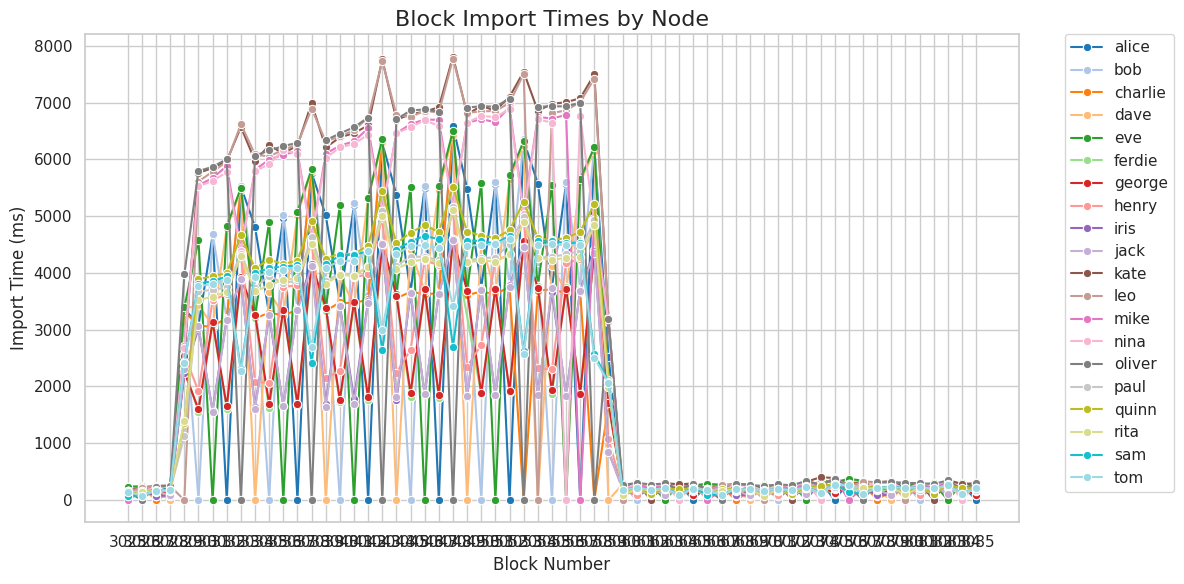

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ---------------------------------------------------------
# STEP 1: INPUT DATA
# ---------------------------------------------------------

filename = '/home/christos/shielded/jupyter/2026-01-14/block_propagation_report.txt'


# ---------------------------------------------------------
# STEP 2: PARSE THE FILE
# ---------------------------------------------------------

data = []
current_block = None

# Regex patterns
block_pattern = re.compile(r"^Block #(\d+)")
import_pattern = re.compile(r"Imported by ([a-zA-Z0-9_]+)")
time_pattern = re.compile(r"after ([\d\.]+) ms")

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        
        # Check for Block Header
        block_match = block_pattern.search(line)
        if block_match:
            current_block = int(block_match.group(1))
            continue
            
        # Check for Import lines
        if "Imported by" in line:
            name_match = import_pattern.search(line)
            if name_match and current_block is not None:
                node_name = name_match.group(1)
                
                # Check if it is the creator (usually 0 ms propagation)
                if "(creator node)" in line:
                    import_time = 0.0
                else:
                    # Extract the millisecond value
                    time_match = time_pattern.search(line)
                    if time_match:
                        import_time = float(time_match.group(1))
                    else:
                        continue # Skip if format doesn't match
                
                data.append({
                    "Block": current_block,
                    "Node": node_name,
                    "ImportTime_ms": import_time
                })

# ---------------------------------------------------------
# STEP 3: CREATE DATAFRAME
# ---------------------------------------------------------

df = pd.DataFrame(data)

# Display the first few rows to check data
print("Extracted Data Sample:")
print(df.head())

# ---------------------------------------------------------
# STEP 4: PLOT THE GRAPH
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a Line Plot
# hue='Node' creates a different color for each node
# marker='o' puts a dot on the data point
plot = sns.lineplot(
    data=df, 
    x="Block", 
    y="ImportTime_ms", 
    hue="Node", 
    marker="o",
    palette="tab20" # A palette good for many categories
)

# Customizing the chart
plt.title("Block Import Times by Node", fontsize=16)
plt.xlabel("Block Number", fontsize=12)
plt.ylabel("Import Time (ms)", fontsize=12)

# Set X-axis to show integer ticks only
plt.xticks(df["Block"].unique())

# Move legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()

# Save the graph
plt.savefig("import_times_graph.png", dpi=300)
print("\nGraph saved as 'import_times_graph.png'")

plt.show()

<Figure size 1000x400 with 0 Axes>

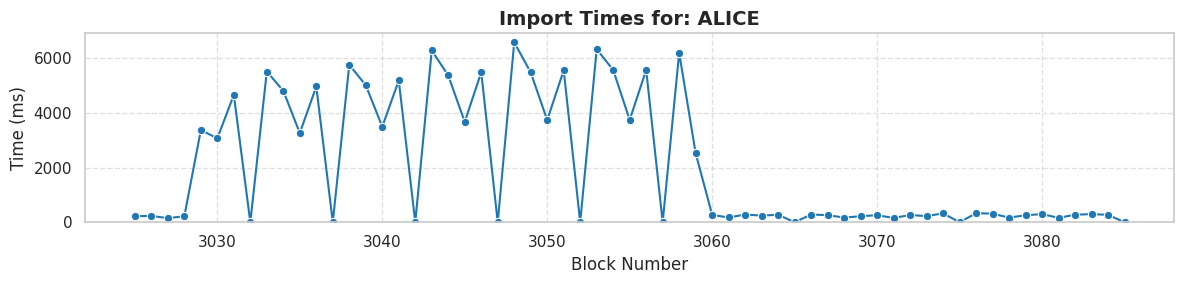

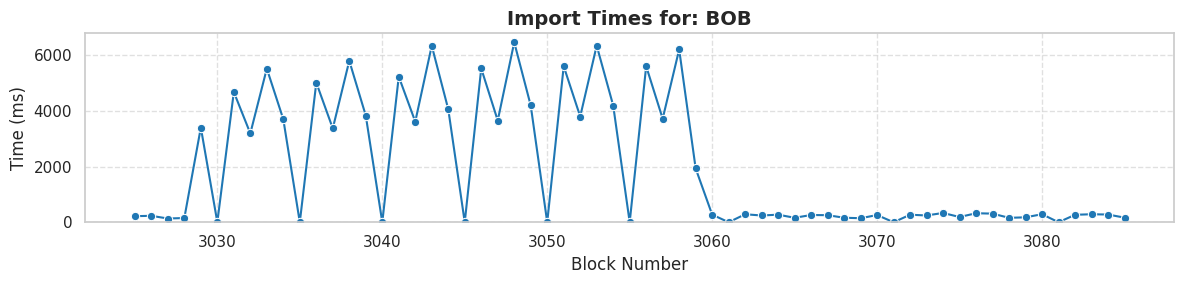

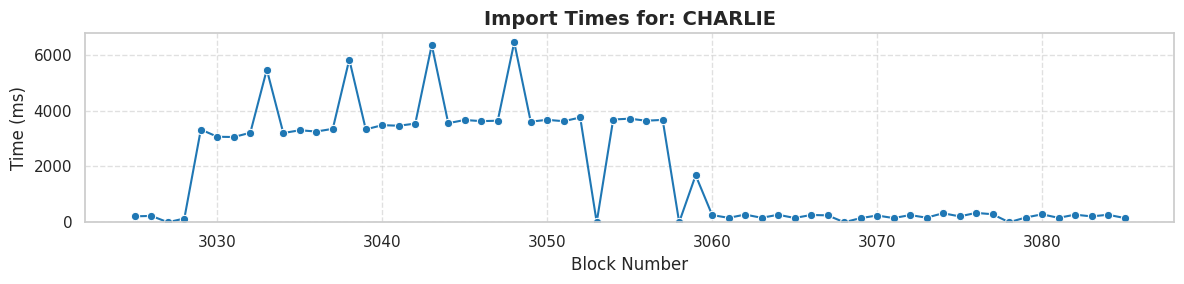

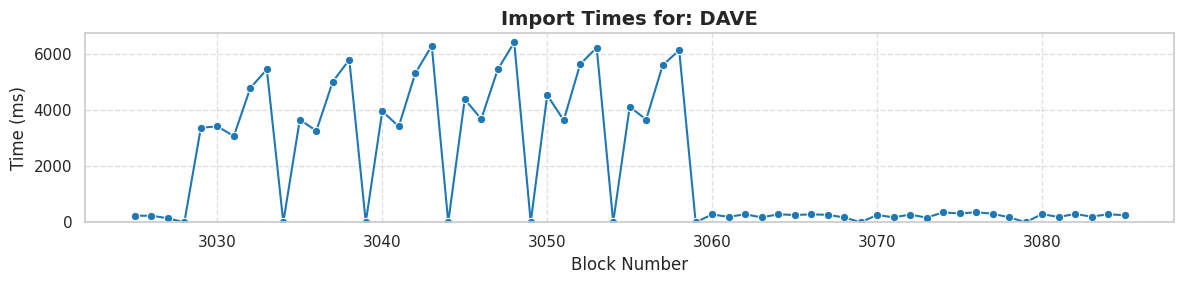

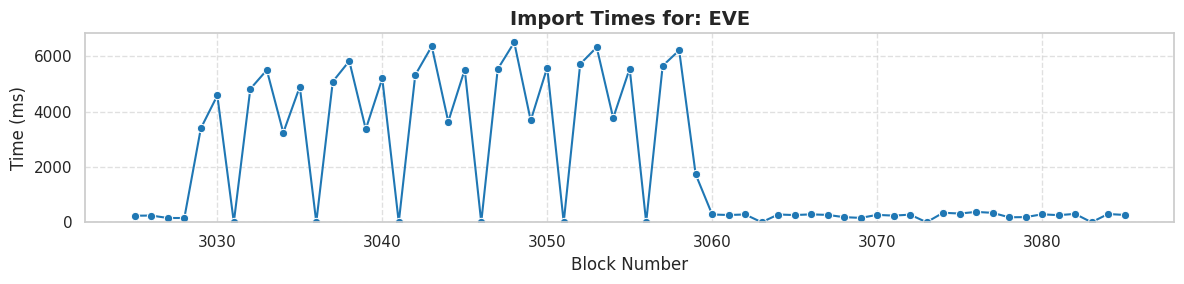

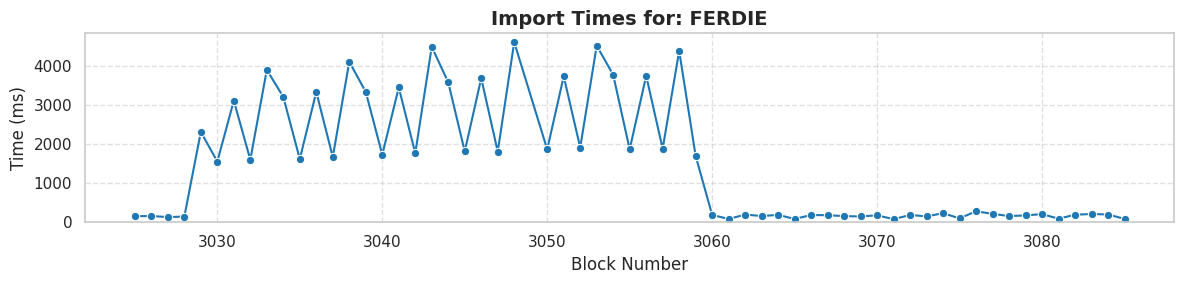

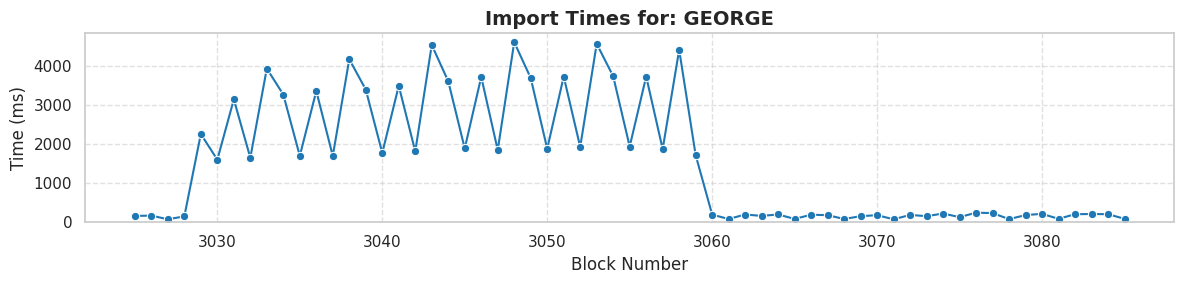

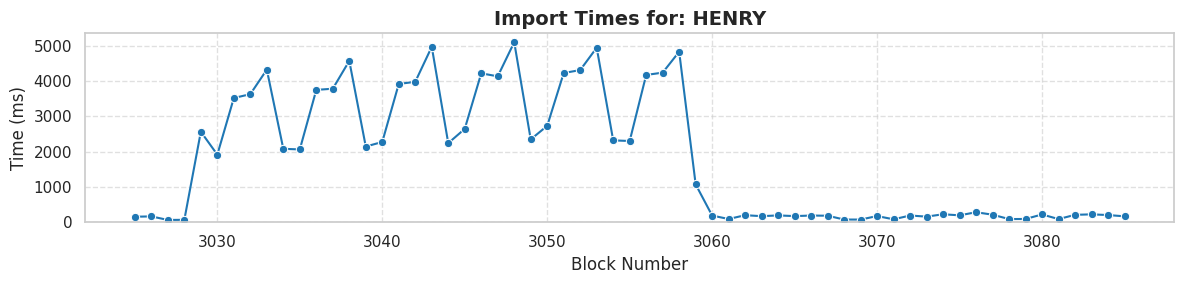

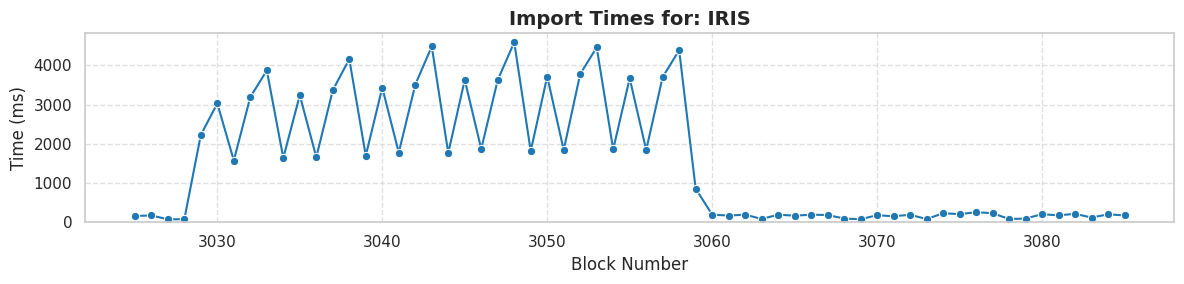

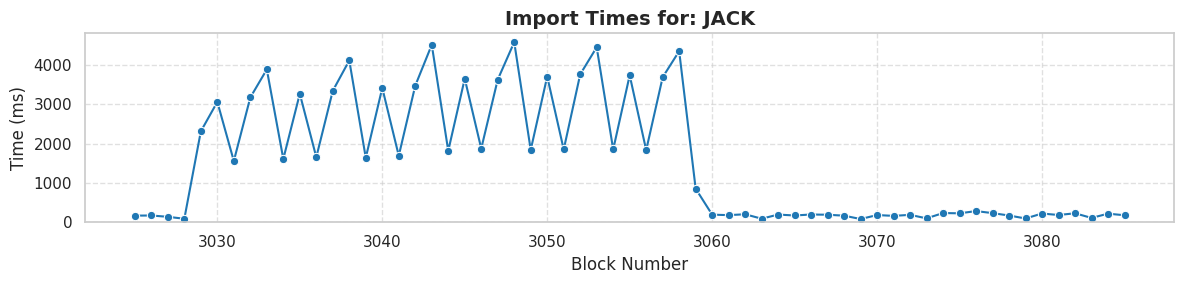

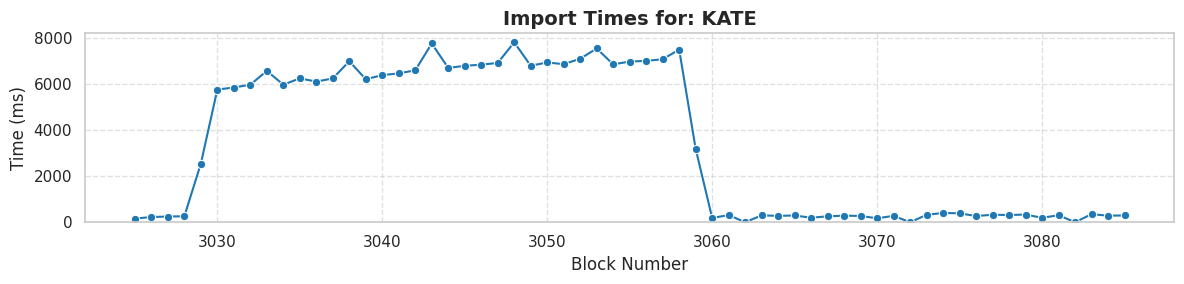

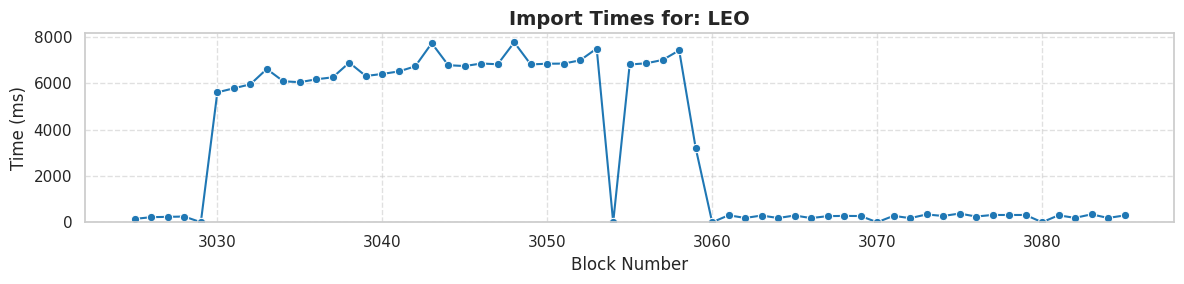

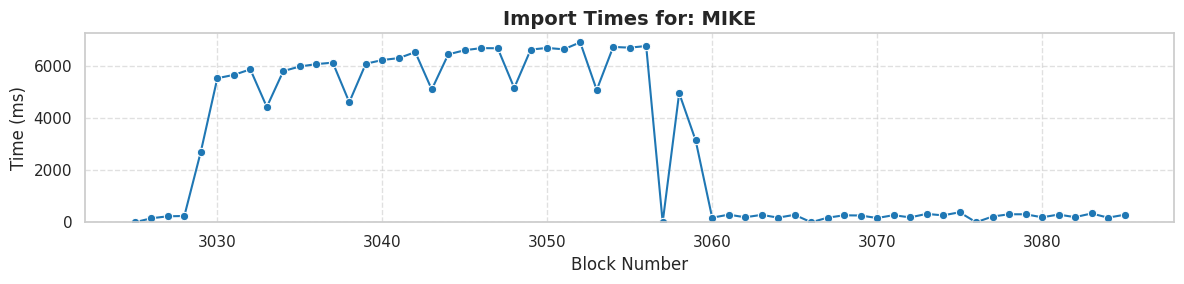

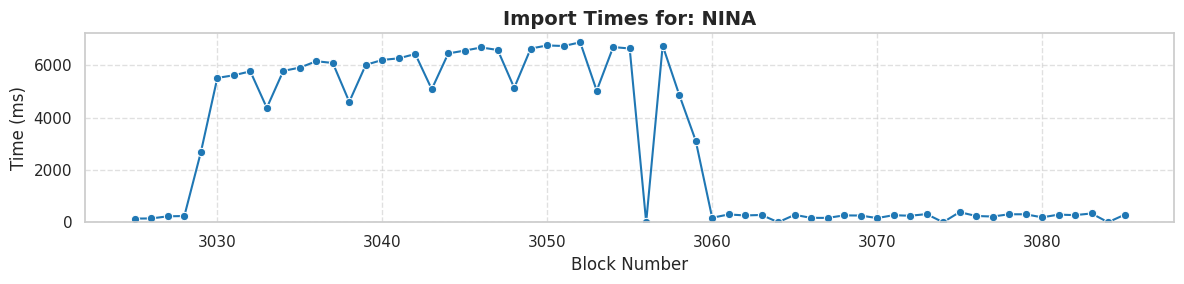

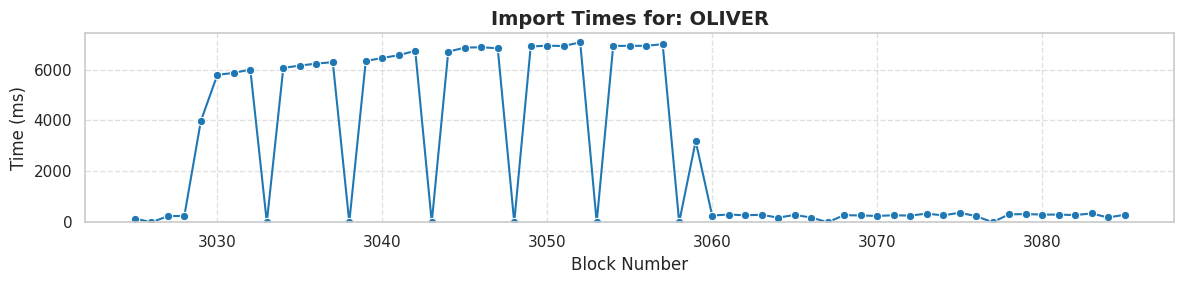

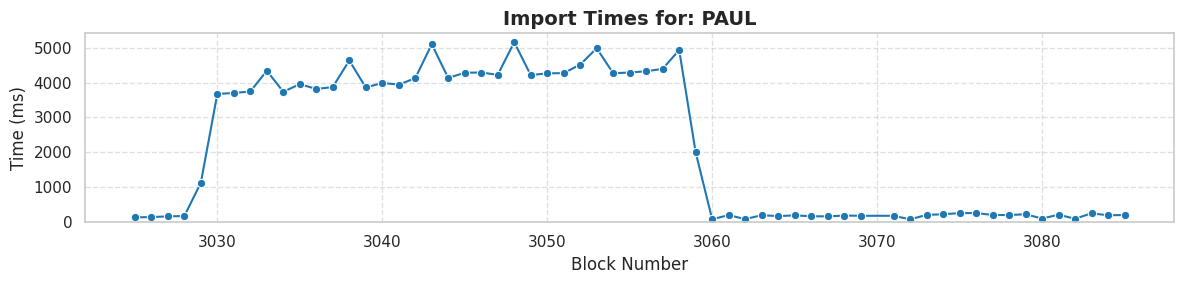

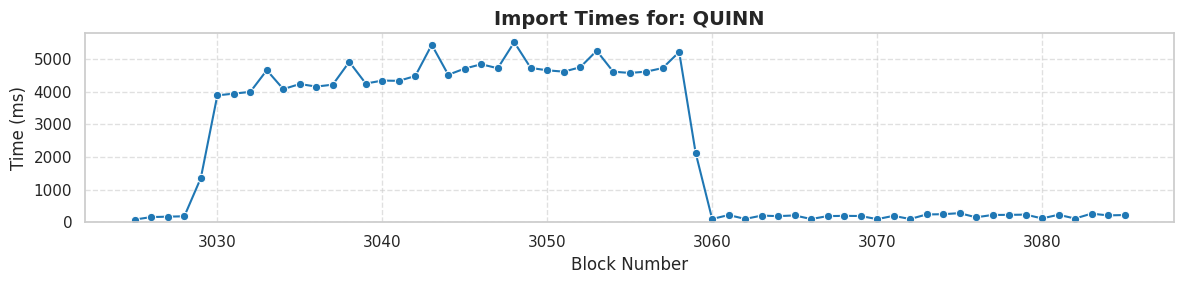

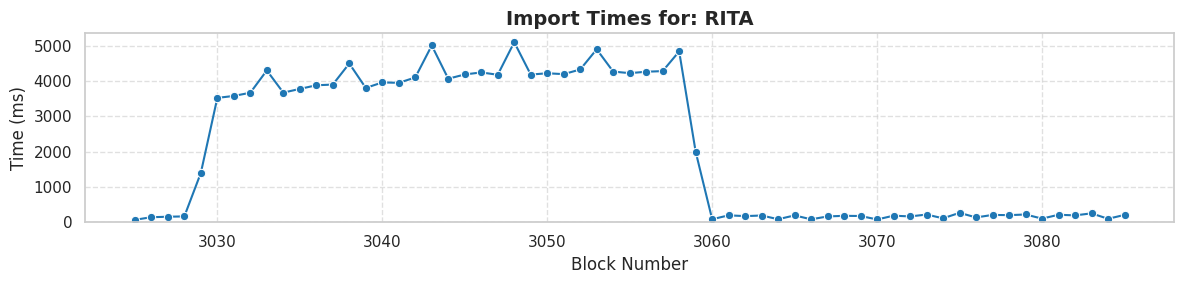

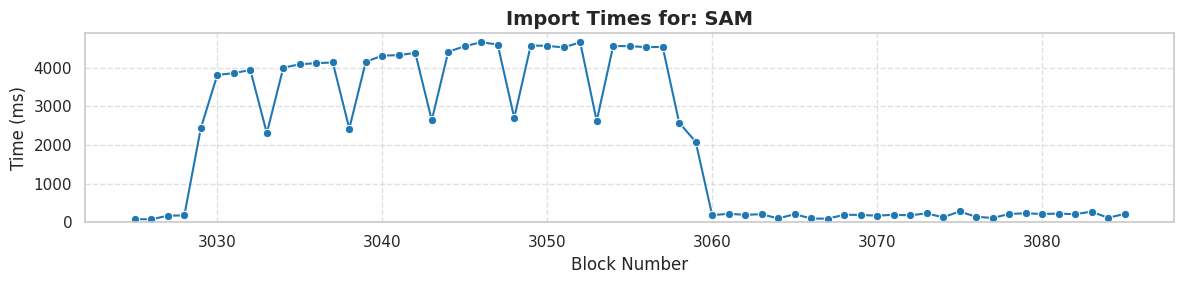

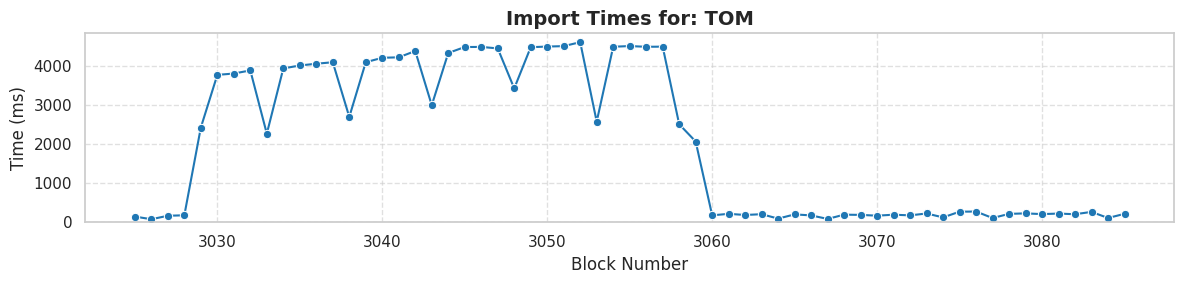

In [2]:
# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Set the size for the individual graphs
plt.figure(figsize=(10, 4)) 

# Loop through each node and create a separate graph
for node in nodes:
    # 1. Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # 2. Create a new figure for this node
    plt.figure(figsize=(12, 3)) # Wide and short format
    
    # 3. Plot the line
    # We use a specific color (e.g., standard blue) or you can keep it colorful
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue' 
    )
    
    # 4. formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # Optional: Force the Y-axis to start at 0 to see scale better
    plt.ylim(bottom=0)
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 5. Display the graph
    plt.show()